# Automatic Classification of Javanese Gamelan Forms from Kepatihan Cipher Notation

This notebook reproduces the complete experimental pipeline for classifying Javanese gamelan compositions by their **bentuk** (cyclic architectural form) directly from symbolic Kepatihan notation PDFs.

**Forms classified (7 classes):** Ayak-Ayak, Bubaran, Ketawang, Ladrang, Lancaran, Sampak, Srepegan

All core logic lives in the `src/` package — this notebook orchestrates the pipeline and visualises results.

## Table of Contents

1. [Setup & Dependencies](#1-setup)
2. [Dataset Overview](#2-dataset)
3. [PDF Parsing & Feature Extraction](#3-parsing)
4. [Exploratory Data Analysis](#4-eda)
5. [Evaluation Protocol](#5-protocol)
6. [Model 1 — Decision Tree](#6-dt)
7. [Model 2 — Random Forest](#7-rf)
8. [Model 3 — Support Vector Machine](#8-svm)
9. [Model 4 — k-Nearest Neighbors](#9-knn)
10. [Model 5 — MLP (Neural Network)](#10-mlp)
11. [Model 6 — 1D CNN](#11-cnn)
12. [Model Comparison](#12-comparison)
13. [Conclusions](#13-conclusions)

---
## 1. Setup & Dependencies <a id='1-setup'></a>

In [1]:
import warnings
warnings.filterwarnings("ignore")

import math
from pathlib import Path
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
)
from sklearn.model_selection import LeaveOneOut, cross_val_predict

import torch

# ── Project modules ──────────────────────────────────────────────────────────
from src.parser import Note, extract_raw_text, parse_notation, pad_or_truncate, N_DIMS
from src.features import extract_features, FEATURE_NAMES, N_FEATURES
from src.data import (
    load_corpus_features, load_corpus_sequences,
    stratified_split, to_arrays, to_tensors,
)
from src.statistical_analysis import (
    load_corpus as load_corpus_parsed, aggregate, all_notes, genre_colors,
)
from src.gamelan_mlp import GamelanMLP, train as train_mlp
from src.gamelan_cnn import GamelanCNN, train_model as train_cnn
from src.plots import plot_embedding_pca

torch.manual_seed(42)
np.random.seed(42)

%matplotlib inline
plt.rcParams.update({"figure.facecolor": "#FAFAF8", "axes.facecolor": "#F8F5F0", "font.size": 10})

PALETTE = ["#E63946", "#457B9D", "#2A9D8F", "#E9C46A", "#F4A261", "#264653", "#A8DADC", "#9B2335"]
DATASET_ROOT = Path("dataset_augmented")

print(f"Dataset path: {DATASET_ROOT.resolve()}")
print(f"Exists: {DATASET_ROOT.exists()}")

Dataset path: /home/frederic/Documents/UPF/semester2/Symbolic/classifying-javanese-gamelan-forms/dataset_augmented
Exists: True


---
## 2. Dataset Overview <a id='2-dataset'></a>

The dataset contains **35 traditional Javanese gamelan compositions** transcribed in Kepatihan cipher notation (Kurniawati et al., *Data in Brief*, 2024). Each composition belongs to one of **7 bentuk** (form categories), with 5 pieces per form.

Each piece folder contains the main melody PDF plus instrument-specific PDFs (Balungan, Bonang, Peking, Structural). For classification, we use only the **main melody PDF** as the input.

In [2]:
dataset_summary = []
for genre_dir in sorted(DATASET_ROOT.iterdir()):
    if not genre_dir.is_dir():
        continue
    for song_dir in sorted(genre_dir.iterdir()):
        if not song_dir.is_dir():
            continue
        main_pdf = song_dir / f"{song_dir.name}.pdf"
        dataset_summary.append({
            "Form (Bentuk)": genre_dir.name,
            "Song": song_dir.name,
            "Main PDF exists": main_pdf.exists(),
            "Total PDFs": len(list(song_dir.glob("*.pdf"))),
        })

df_dataset = pd.DataFrame(dataset_summary)
print(f"Total pieces: {len(df_dataset)}")
print(f"Forms: {df_dataset['Form (Bentuk)'].nunique()}")
print(f"\nPieces per form:")
print(df_dataset.groupby("Form (Bentuk)").size().to_string())
print()
df_dataset

Total pieces: 192
Forms: 7

Pieces per form:
Form (Bentuk)
Ayak Ayak    11
Bubaran      28
Ketawang     29
Ladrang      25
Lancaran     29
Sampak       45
Srepegan     25



,Form (Bentuk),Song,Main PDF exists,Total PDFs
0,Ayak Ayak,Ayak Ayak Manyura Slendro Manyura,True,1
1,Ayak Ayak,Ayak Ayak Manyura Slendro Manyura shift+1,True,1
2,Ayak Ayak,Ayak Ayak Nem Slendro Nem,True,1
3,Ayak Ayak,Ayak Ayak Nem Slendro Nem shift+1,True,1
4,Ayak Ayak,Ayak Ayak Nem Slendro Nem shift+2,True,1
...,...,...,...,...
187,Srepegan,Srepegan Tlutur Slendro Sanga,True,1
188,Srepegan,Srepegan Tlutur Slendro Sanga shift+1,True,1
189,Srepegan,Srepegan Tlutur Slendro Sanga shift+2,True,1
190,Srepegan,Srepegan Tlutur Slendro Sanga shift+3,True,1


---
## 3. PDF Parsing & Feature Extraction <a id='3-parsing'></a>

The PDF scores use a custom **Balungan TrueType font** where each letter maps to a specific pitch and octave. Our parser (`src/parser.py`) decodes these glyphs into structured note events.

### 3.1 Parsing a single piece (demonstration)

In [3]:
demo_pdf = DATASET_ROOT / "Lancaran" / "Lancaran Manyar Sewu Slendro Manyura" / "Lancaran Manyar Sewu Slendro Manyura.pdf"
raw_text = extract_raw_text(str(demo_pdf))
parsed = parse_notation(raw_text)

print(f"Title : {parsed['title']}")
print(f"Laras : {parsed['laras']}")
print(f"Pathet: {parsed['pathet']}")
print(f"Sections: {len(parsed['sections'])}")
for sec in parsed["sections"]:
    notes = [n for n in sec["notes"] if isinstance(n, Note)]
    sounding = [n for n in notes if not n.is_rest]
    print(f"  {sec['name']:10s} — {len(notes)} events ({len(sounding)} sounding, {len(notes)-len(sounding)} rests)")

print(f"\nFeature vector ({N_FEATURES} dims):")
feats = extract_features(parsed)
for name, val in zip(FEATURE_NAMES, feats):
    print(f"  {name:25s} {val:.4f}")

Title : Lancaran Manyarséwu, laras sléndro pathet manyura
Laras : sléndro
Pathet: manyura
Sections: 1
  Buka       — 76 events (38 sounding, 38 rests)

Feature vector (29 dims):
  pitch_1_%                 0.1579
  pitch_2_%                 0.1053
  pitch_3_%                 0.2368
  pitch_4_%                 0.0000
  pitch_5_%                 0.2368
  pitch_6_%                 0.2632
  pitch_7_%                 0.0000
  reg_low_%                 0.0000
  reg_mid_%                 0.8421
  reg_high_%                0.1579
  marker_density            0.7632
  rest_ratio                0.5000
  step_ratio                0.6757
  leap_ratio                0.3243
  mean_abs_interval         2.5946
  gong_cycle_mean           15.2000
  gong_cycle_std            1.6000
  gong_cycle_count          5.0000
  has_repeat                1.0000
  repeat_count              1.0000
  has_Buka                  1.0000
  has_Merong                0.0000
  has_Inggah                0.0000
  has_Ngelik    

### 3.2 Load full corpus — feature extraction

Uses `src.data.load_corpus_features()` to parse all 35 PDFs and extract 29-dim feature vectors.

In [4]:
print("Loading corpus (features)...\n")
records = load_corpus_features(DATASET_ROOT)
print(f"\nLoaded {len(records)} pieces.")

X_feat, y, le = to_arrays(records)
class_names = list(le.classes_)
n_classes = len(class_names)

print(f"Feature matrix shape: {X_feat.shape}")
print(f"Classes ({n_classes}): {class_names}")
print(f"\nSamples per class:")
for i, name in enumerate(class_names):
    print(f"  {name}: {(y == i).sum()}")

Loading corpus (features)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura shift+1
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+1
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+2
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+3
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+4
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift-1
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+1
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+2
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+3
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+4
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem shift+1
  ✅  Bubaran / Bubaran Kembang Pacar Pelog 

### 3.3 Feature overview

In [5]:
df_features = pd.DataFrame(X_feat, columns=FEATURE_NAMES)
df_features["genre"] = [r["genre"] for r in records]
df_features["song"] = [r["song_name"] for r in records]

print("Feature statistics:")
df_features[FEATURE_NAMES].describe().round(3)

Feature statistics:


,pitch_1_%,pitch_2_%,pitch_3_%,pitch_4_%,pitch_5_%,pitch_6_%,pitch_7_%,reg_low_%,reg_mid_%,reg_high_%,...,repeat_count,has_Buka,has_Merong,has_Inggah,has_Ngelik,has_Umpak,has_Suwuk,pitch_entropy,ascending_ratio,direction_changes
count,192.000,192.000,192.000,192.000,192.000,192.000,192.000,192.000,192.000,192.000,...,192.000,192.000,192.0,192.0,192.000,192.0,192.000,192.000,192.000,192.000
mean,0.131,0.159,0.143,0.134,0.157,0.149,0.123,0.200,0.590,0.205,...,1.042,0.974,0.0,0.0,0.240,0.0,0.417,2.229,0.370,0.417
std,0.117,0.113,0.114,0.117,0.111,0.118,0.109,0.206,0.210,0.197,...,0.456,0.160,0.0,0.0,0.428,0.0,0.494,0.284,0.158,0.256
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,...,0.000,0.000,0.0,0.0,0.000,0.0,0.000,0.000,0.000,0.000
25%,0.014,0.072,0.019,0.013,0.063,0.026,0.013,0.045,0.452,0.021,...,1.000,1.000,0.0,0.0,0.000,0.0,0.000,2.118,0.370,0.321
50%,0.123,0.152,0.143,0.138,0.156,0.141,0.115,0.140,0.581,0.156,...,1.000,1.000,0.0,0.0,0.000,0.0,0.000,2.252,0.443,0.521
75%,0.215,0.237,0.226,0.216,0.233,0.237,0.204,0.290,0.736,0.356,...,1.000,1.000,0.0,0.0,0.000,0.0,1.000,2.433,0.467,0.568
max,0.429,0.429,0.429,0.429,0.429,0.429,0.429,0.959,1.000,0.658,...,7.000,1.000,0.0,0.0,1.000,0.0,1.000,2.598,0.548,0.811


---
## 4. Exploratory Data Analysis <a id='4-eda'></a>

Uses `src.statistical_analysis` to compute and visualise per-genre statistics.

In [6]:
print("Loading corpus (parsed notation for EDA)...\n")
corpus = load_corpus_parsed(DATASET_ROOT)
genre_stats = aggregate(corpus)
genres = sorted(genre_stats)
colors = genre_colors(genres)
print(f"\nGenres: {genres}")
for g in genres:
    s = genre_stats[g]
    print(f"  {g}: {s['n_pieces']} pieces, {s['total_notes']} notes")

Loading corpus (parsed notation for EDA)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura shift+1
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+1
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+2
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+3
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+4
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift-1
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+1
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+2
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+3
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+4
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem
  ✅  Bubaran / Bubaran Kembang Pacar Pelog Nem shift+1
  ✅  Bubaran / Bubaran Kemba

### 4.1 Pitch distribution by genre

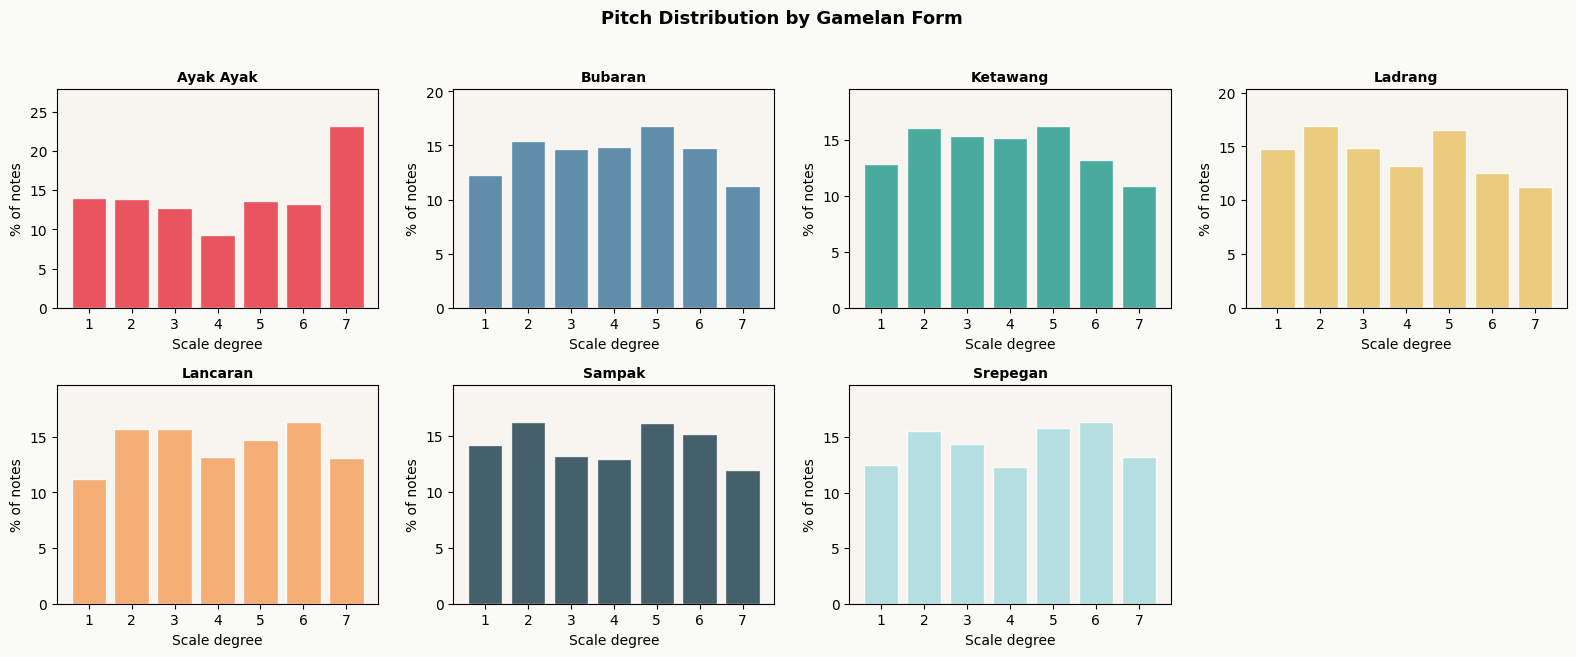

In [7]:
pitches_range = [1, 2, 3, 4, 5, 6, 7]
cols = min(4, len(genres))
rows = math.ceil(len(genres) / cols)

fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 3.2))
axes = np.array(axes).flatten()

for i, genre in enumerate(genres):
    ax = axes[i]
    pd_g = genre_stats[genre]["pitch_dist"]
    tot = sum(pd_g.values()) or 1
    vals = [pd_g.get(p, 0) / tot * 100 for p in pitches_range]
    ax.bar([str(p) for p in pitches_range], vals, color=colors[genre], alpha=0.85, edgecolor="white")
    ax.set_title(genre, fontsize=10, fontweight="bold")
    ax.set_xlabel("Scale degree")
    ax.set_ylabel("% of notes")
    ax.set_ylim(0, max(vals) * 1.2 if vals else 10)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

fig.suptitle("Pitch Distribution by Gamelan Form", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 4.2 Register usage

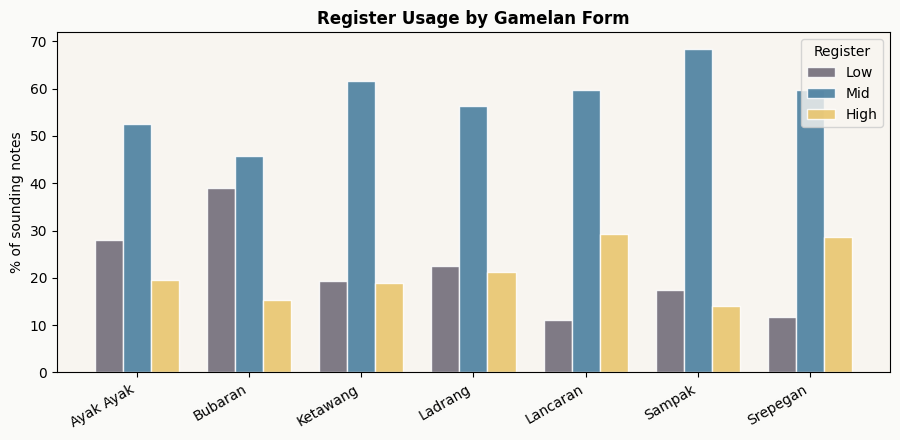

In [8]:
reg_labels = ["Low", "Mid", "High"]
reg_keys = [-1, 0, 1]
reg_colors = ["#6D6875", "#457B9D", "#E9C46A"]

fig, ax = plt.subplots(figsize=(max(8, len(genres) * 1.3), 4.5))
x = np.arange(len(genres))
width = 0.25

for k, (reg, lab, rc) in enumerate(zip(reg_keys, reg_labels, reg_colors)):
    vals = []
    for g in genres:
        rd = genre_stats[g]["register_dist"]
        tot = sum(rd.values()) or 1
        vals.append(rd.get(reg, 0) / tot * 100)
    ax.bar(x + k * width, vals, width, label=lab, color=rc, alpha=0.87, edgecolor="white")

ax.set_xticks(x + width)
ax.set_xticklabels(genres, rotation=30, ha="right")
ax.legend(title="Register")
ax.set_ylabel("% of sounding notes")
ax.set_title("Register Usage by Gamelan Form", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 4.3 Melodic intervals and gong cycle structure

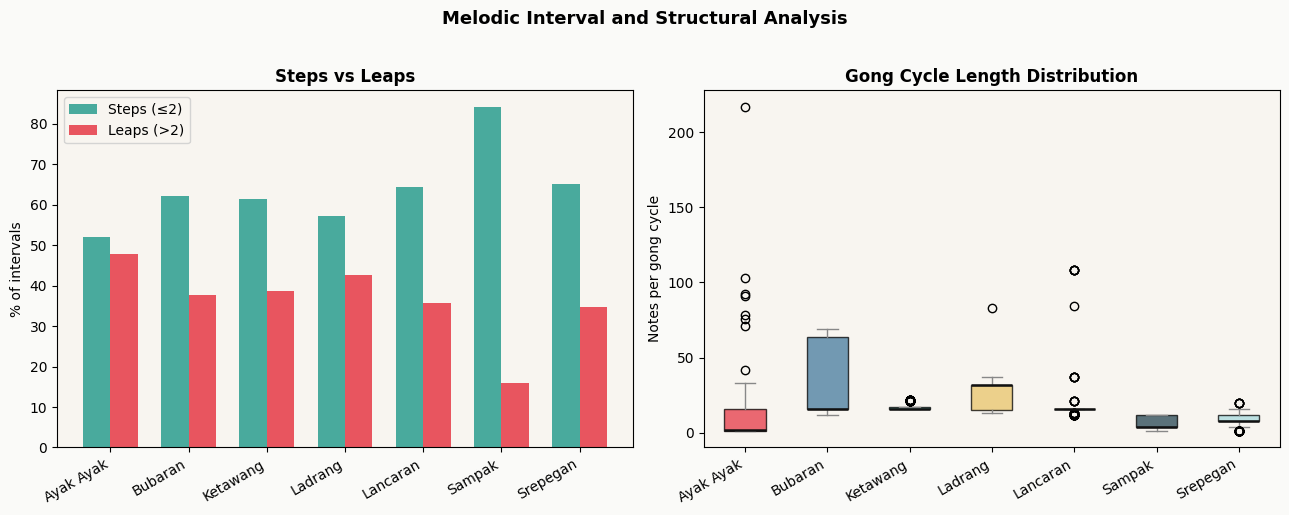

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(genres))
w = 0.35
step_ratios = [genre_stats[g]["interval_stats"]["step_ratio"] * 100 for g in genres]
leap_ratios = [genre_stats[g]["interval_stats"]["leap_ratio"] * 100 for g in genres]
ax1.bar(x - w/2, step_ratios, w, label="Steps (\u22642)", color="#2A9D8F", alpha=0.85)
ax1.bar(x + w/2, leap_ratios, w, label="Leaps (>2)", color="#E63946", alpha=0.85)
ax1.set_xticks(x)
ax1.set_xticklabels(genres, rotation=30, ha="right")
ax1.legend()
ax1.set_ylabel("% of intervals")
ax1.set_title("Steps vs Leaps", fontweight="bold")

gong_data = [genre_stats[g]["gong_densities"] for g in genres if genre_stats[g]["gong_densities"]]
gong_genres = [g for g in genres if genre_stats[g]["gong_densities"]]
if gong_data:
    bp = ax2.boxplot(gong_data, patch_artist=True,
                     medianprops=dict(color="#111", linewidth=1.8),
                     whiskerprops=dict(color="#888"), capprops=dict(color="#888"))
    for patch, g in zip(bp["boxes"], gong_genres):
        patch.set_facecolor(colors[g])
        patch.set_alpha(0.75)
    ax2.set_xticklabels(gong_genres, rotation=30, ha="right")
    ax2.set_ylabel("Notes per gong cycle")
    ax2.set_title("Gong Cycle Length Distribution", fontweight="bold")

fig.suptitle("Melodic Interval and Structural Analysis", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

### 4.4 Section occurrence heatmap

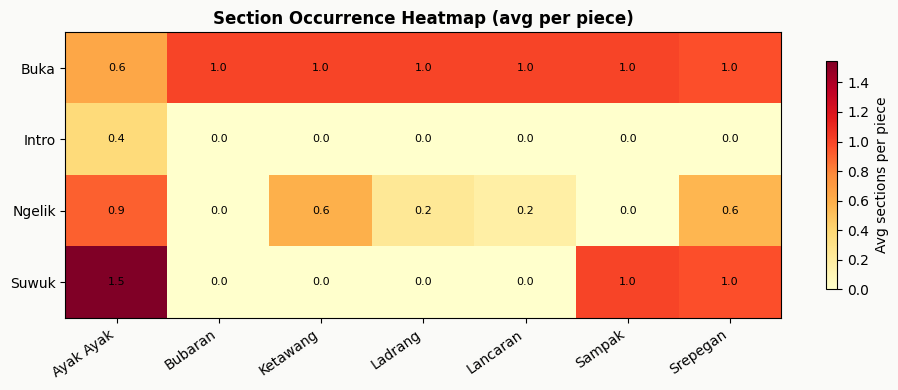

In [10]:
all_sec_types = sorted({s for g in genres for s in genre_stats[g]["section_counts"].keys()})

matrix = np.array([
    [genre_stats[g]["section_counts"].get(s, 0) / (genre_stats[g]["n_pieces"] or 1)
     for g in genres]
    for s in all_sec_types
], dtype=float)

fig, ax = plt.subplots(figsize=(max(9, len(genres) * 1.4), max(4, len(all_sec_types) * 0.7)))
im = ax.imshow(matrix, aspect="auto", cmap="YlOrRd", interpolation="nearest")
ax.set_xticks(range(len(genres)))
ax.set_xticklabels(genres, rotation=35, ha="right")
ax.set_yticks(range(len(all_sec_types)))
ax.set_yticklabels(all_sec_types)
for i in range(len(all_sec_types)):
    for j in range(len(genres)):
        ax.text(j, i, f"{matrix[i, j]:.1f}", ha="center", va="center",
                fontsize=8, color="black" if matrix[i, j] < 3 else "white")
plt.colorbar(im, ax=ax, label="Avg sections per piece", shrink=0.8)
ax.set_title("Section Occurrence Heatmap (avg per piece)", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.show()

### 4.5 Radar overview

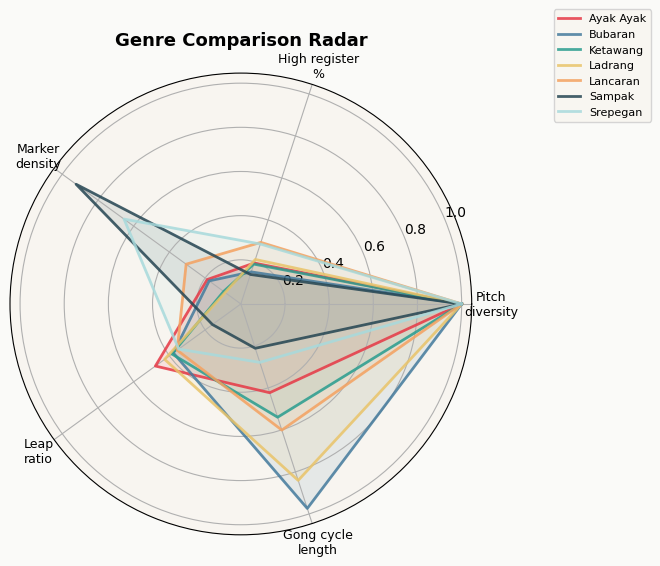

In [11]:
dimensions = ["Pitch\ndiversity", "High register\n%", "Marker\ndensity", "Leap\nratio", "Gong cycle\nlength"]

def extract_radar(g):
    s = genre_stats[g]
    pd_g = s["pitch_dist"]
    total = sum(pd_g.values()) or 1
    pitch_div = len([v for v in pd_g.values() if v / total > 0.05]) / 7
    hi_reg = s["register_dist"].get(1, 0) / (sum(s["register_dist"].values()) or 1)
    marker = min(s["marker_density"] / 2.0, 1.0)
    leap = s["interval_stats"]["leap_ratio"]
    gong_mean = np.mean(s["gong_densities"]) / 32 if s["gong_densities"] else 0
    return [pitch_div, hi_reg, marker, leap, min(gong_mean, 1.0)]

N_dims = len(dimensions)
angles = np.linspace(0, 2 * np.pi, N_dims, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for genre in genres:
    vals = extract_radar(genre) + extract_radar(genre)[:1]
    ax.plot(angles, vals, color=colors[genre], linewidth=2, alpha=0.85, label=genre)
    ax.fill(angles, vals, color=colors[genre], alpha=0.1)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(dimensions, fontsize=9)
ax.set_title("Genre Comparison Radar", fontsize=13, fontweight="bold", pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.4, 1.15), fontsize=8)
fig.tight_layout()
plt.show()

### 4.6 Feature correlation matrix

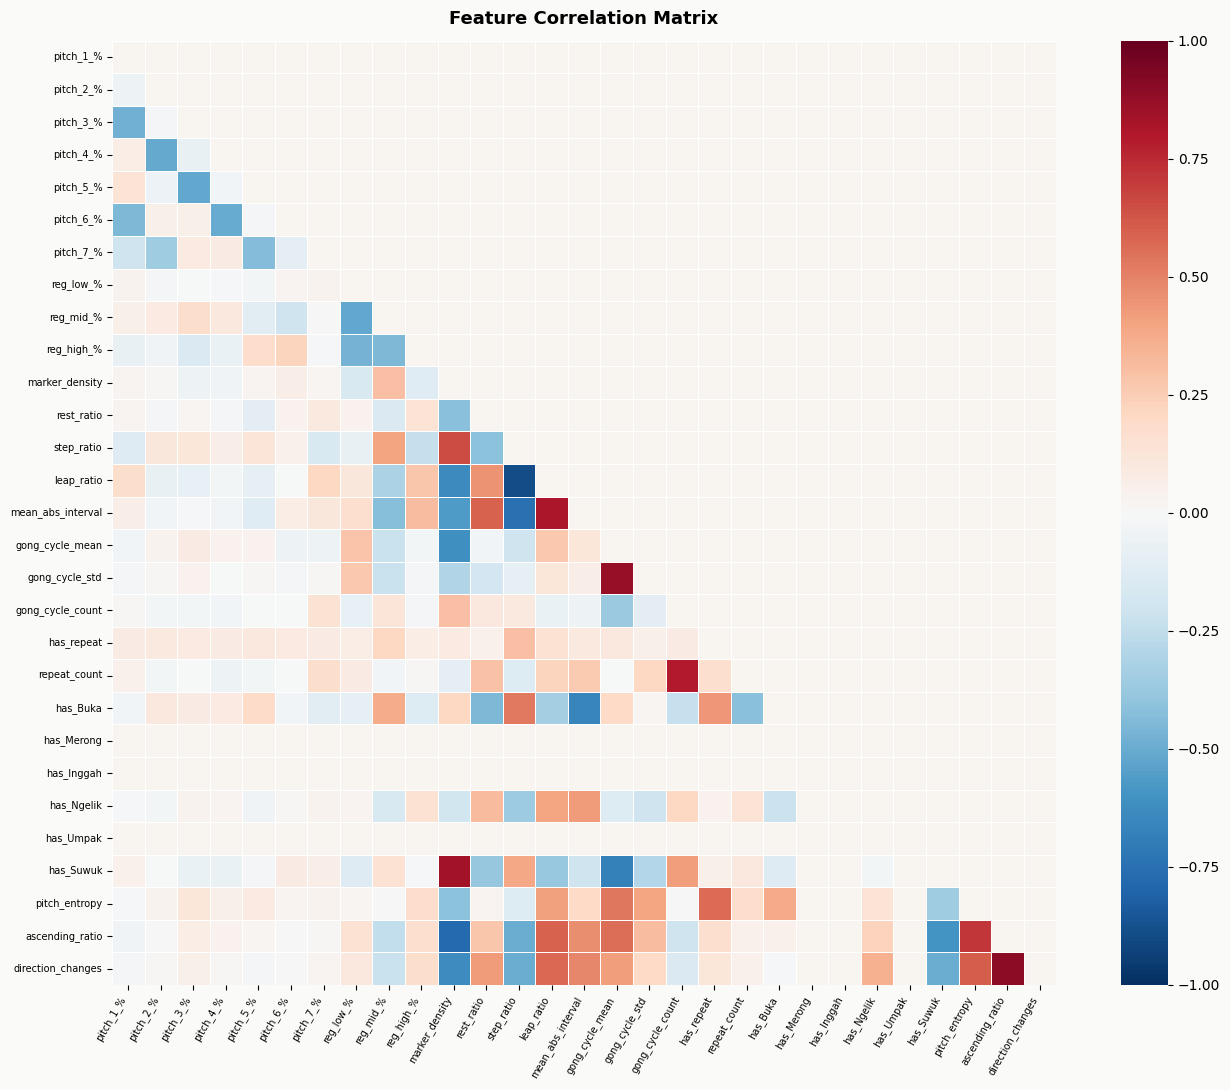

In [12]:
fig, ax = plt.subplots(figsize=(14, 11))
corr = df_features[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap="RdBu_r", center=0, annot=False,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1,
            xticklabels=FEATURE_NAMES, yticklabels=FEATURE_NAMES)
ax.set_title("Feature Correlation Matrix", fontsize=13, fontweight="bold", pad=12)
plt.xticks(rotation=60, ha="right", fontsize=7)
plt.yticks(fontsize=7)
fig.tight_layout()
plt.show()

---
## 5. Evaluation Protocol <a id='5-protocol'></a>

Given the small dataset (35 pieces, 7 classes), a single train/test split is unreliable. We use two complementary evaluation strategies:

1. **Leave-One-Out Cross-Validation (LOGOCV):** Train on 34 pieces, test on 1, repeat 35 times. Most unbiased accuracy estimate for small datasets.
2. **Stratified hold-out split (4 train / 1 test per genre):** Uses `src.data.stratified_split()`. Used for visualization and neural model training.

In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_feat)

# Stratified hold-out via src.data
train_records, test_records = stratified_split(records)
X_train, y_train, _ = to_arrays(train_records, le)
X_test, y_test, _ = to_arrays(test_records, le)

# Scaled versions for models that need it
scaler_split = StandardScaler().fit(X_train)
X_train_s = scaler_split.transform(X_train).astype(np.float32)
X_test_s = scaler_split.transform(X_test).astype(np.float32)

loo = LeaveOneOut()

print(f"Hold-out split: {len(train_records)} train / {len(test_records)} test")
print(f"Train genres: {Counter(y_train)}")
print(f"Test  genres: {Counter(y_test)}")

  Ayak Ayak: 5 originals → 10 train pieces / 1 test pieces
  Bubaran: 5 originals → 23 train pieces / 5 test pieces
  Ketawang: 5 originals → 23 train pieces / 6 test pieces
  Ladrang: 5 originals → 24 train pieces / 1 test pieces
  Lancaran: 5 originals → 24 train pieces / 5 test pieces
  Sampak: 5 originals → 36 train pieces / 9 test pieces
  Srepegan: 5 originals → 20 train pieces / 5 test pieces
Hold-out split: 160 train / 32 test
Train genres: Counter({np.int64(5): 36, np.int64(3): 24, np.int64(4): 24, np.int64(1): 23, np.int64(2): 23, np.int64(6): 20, np.int64(0): 10})
Test  genres: Counter({np.int64(5): 9, np.int64(2): 6, np.int64(1): 5, np.int64(4): 5, np.int64(6): 5, np.int64(0): 1, np.int64(3): 1})


---
## 6. Model 1 — Decision Tree <a id='6-dt'></a>

A `DecisionTreeClassifier` with a depth sweep to find the best generalising depth. This model provides full explainability through its decision rules.

In [32]:
from sklearn.model_selection import LeaveOneGroupOut
import re

_AUG_SUFFIX = re.compile(r"\s+shift[+-]\d+$")

# One group ID per original piece — all transpositions of the same original
# share the same integer ID, so LeaveOneGroupOut holds them out together.
original_names = [_AUG_SUFFIX.sub("", r["song_name"]) for r in records]
unique_originals = sorted(set(original_names))
orig_to_id = {name: i for i, name in enumerate(unique_originals)}
groups = np.array([orig_to_id[name] for name in original_names])

logo = LeaveOneGroupOut()

print(f"Unique original pieces (groups): {len(unique_originals)}")
print(f"Samples per group (min/max): {np.bincount(groups).min()} / {np.bincount(groups).max()}")
print(f"Number of LOGO folds: {logo.get_n_splits(X_feat, y, groups)}")

Unique original pieces (groups): 35
Samples per group (min/max): 1 / 9
Number of LOGO folds: 35


In [33]:
best_loo_acc_dt = 0
best_depth_dt = 1

for depth in range(1, 16):
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    y_pred_loo = cross_val_predict(dt, X_feat, y, cv=logo, groups=groups)
    acc = accuracy_score(y, y_pred_loo)
    if acc > best_loo_acc_dt:
        best_loo_acc_dt = acc
        best_depth_dt = depth

dt_final = DecisionTreeClassifier(max_depth=best_depth_dt, random_state=42)
y_pred_dt_loo = cross_val_predict(dt_final, X_feat, y, cv=logo, groups=groups)
dt_loo_acc = accuracy_score(y, y_pred_dt_loo)
dt_loo_f1 = f1_score(y, y_pred_dt_loo, average="macro")

print(f"Decision Tree — LOGOCV Results")
print(f"  Best depth: {best_depth_dt}")
print(f"  Accuracy:   {dt_loo_acc:.1%}")
print(f"  Macro F1:   {dt_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_dt_loo, target_names=class_names, zero_division=0))

Decision Tree — LOGOCV Results
  Best depth: 6
  Accuracy:   84.4%
  Macro F1:   0.838

              precision    recall  f1-score   support

   Ayak Ayak       1.00      0.91      0.95        11
     Bubaran       0.69      0.39      0.50        28
    Ketawang       0.96      0.79      0.87        29
     Ladrang       1.00      1.00      1.00        25
    Lancaran       0.59      0.83      0.69        29
      Sampak       0.98      1.00      0.99        45
    Srepegan       0.80      0.96      0.87        25

    accuracy                           0.84       192
   macro avg       0.86      0.84      0.84       192
weighted avg       0.85      0.84      0.84       192



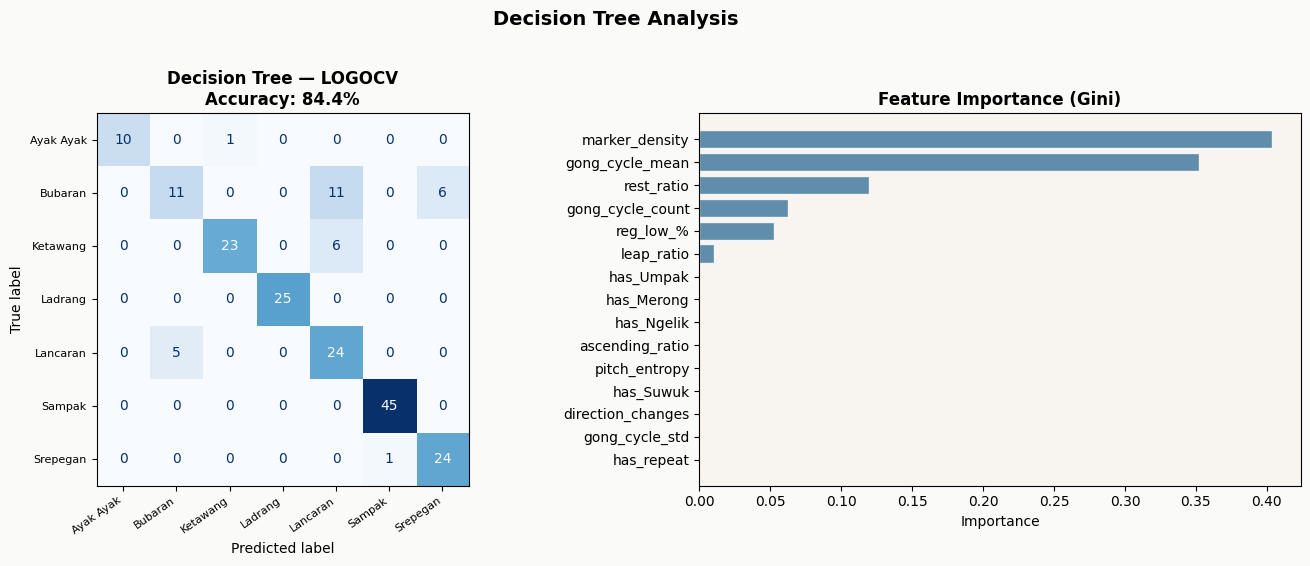

In [34]:
dt_full = DecisionTreeClassifier(max_depth=best_depth_dt, random_state=42)
dt_full.fit(X_feat, y)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

cm_loo = confusion_matrix(y, y_pred_dt_loo)
ConfusionMatrixDisplay(cm_loo, display_labels=class_names).plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title(f"Decision Tree — LOGOCV\nAccuracy: {dt_loo_acc:.1%}", fontweight="bold")
ax1.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax1.set_yticklabels(class_names, fontsize=8)

imp = dt_full.feature_importances_
top_k = min(15, N_FEATURES)
idx = np.argsort(imp)[::-1][:top_k]
ax2.barh([FEATURE_NAMES[i] for i in idx][::-1], [imp[i] for i in idx][::-1],
         color="#457B9D", alpha=0.85, edgecolor="white")
ax2.set_title("Feature Importance (Gini)", fontweight="bold")
ax2.set_xlabel("Importance")

fig.suptitle("Decision Tree Analysis", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

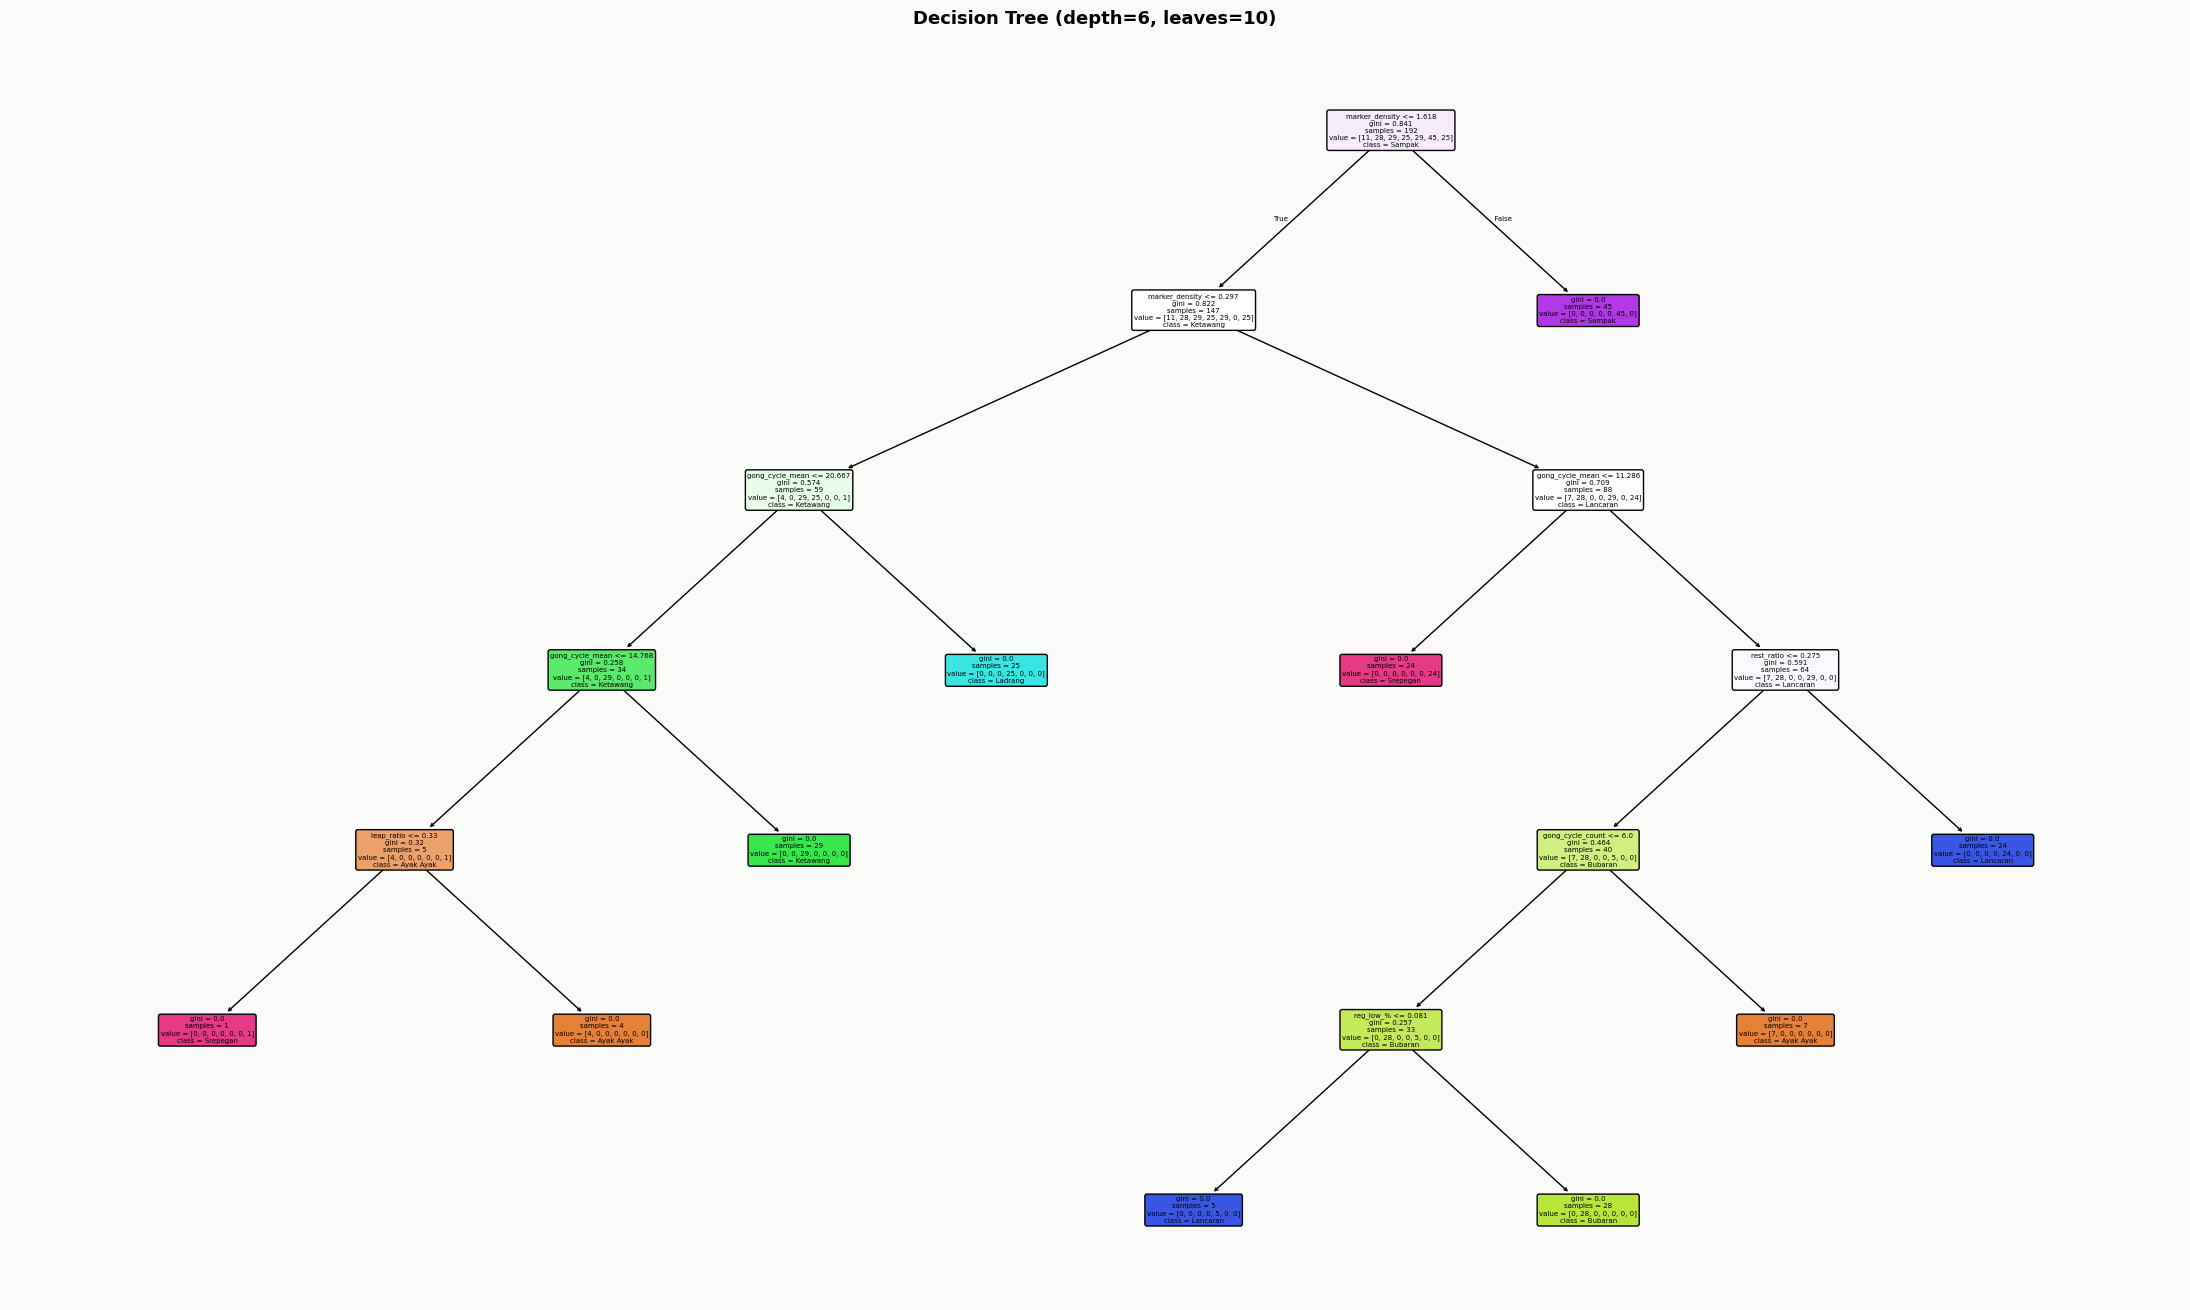


── Decision Rules ──
|--- marker_density <= 1.62
|   |--- marker_density <= 0.30
|   |   |--- gong_cycle_mean <= 20.67
|   |   |   |--- gong_cycle_mean <= 14.77
|   |   |   |   |--- leap_ratio <= 0.33
|   |   |   |   |   |--- class: 6
|   |   |   |   |--- leap_ratio >  0.33
|   |   |   |   |   |--- class: 0
|   |   |   |--- gong_cycle_mean >  14.77
|   |   |   |   |--- class: 2
|   |   |--- gong_cycle_mean >  20.67
|   |   |   |--- class: 3
|   |--- marker_density >  0.30
|   |   |--- gong_cycle_mean <= 11.29
|   |   |   |--- class: 6
|   |   |--- gong_cycle_mean >  11.29
|   |   |   |--- rest_ratio <= 0.27
|   |   |   |   |--- gong_cycle_count <= 6.00
|   |   |   |   |   |--- reg_low_% <= 0.08
|   |   |   |   |   |   |--- class: 4
|   |   |   |   |   |--- reg_low_% >  0.08
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- gong_cycle_count >  6.00
|   |   |   |   |   |--- class: 0
|   |   |   |--- rest_ratio >  0.27
|   |   |   |   |--- class: 4
|--- marker_density >  1.62
| 

In [35]:
n_leaves = dt_full.get_n_leaves()
depth = dt_full.get_depth()
fig, ax = plt.subplots(figsize=(max(18, n_leaves * 2.2), max(7, depth * 2.2)))
plot_tree(dt_full, ax=ax, feature_names=FEATURE_NAMES, class_names=class_names,
          filled=True, rounded=True, impurity=True, proportion=False,
          fontsize=max(5, min(9, 50 // max(n_leaves, 1))))
ax.set_title(f"Decision Tree (depth={depth}, leaves={n_leaves})", fontsize=13, fontweight="bold", pad=12)
fig.tight_layout()
plt.show()

print("\n── Decision Rules ──")
print(export_text(dt_full, feature_names=list(FEATURE_NAMES), max_depth=best_depth_dt))

---
## 7. Model 2 — Random Forest <a id='7-rf'></a>

An ensemble of decision trees to reduce variance and improve generalisation.

In [36]:
best_loo_acc_rf = 0
best_n_estimators = 50

for n_est in [50, 100, 200, 300]:
    rf = RandomForestClassifier(n_estimators=n_est, max_depth=best_depth_dt + 2, random_state=42)
    y_pred_loo_rf = cross_val_predict(rf, X_feat, y, cv=logo, groups=groups)
    acc = accuracy_score(y, y_pred_loo_rf)
    if acc > best_loo_acc_rf:
        best_loo_acc_rf = acc
        best_n_estimators = n_est

rf_final = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_depth_dt + 2, random_state=42)
y_pred_rf_loo = cross_val_predict(rf_final, X_feat, y, cv=logo, groups=groups)
rf_loo_acc = accuracy_score(y, y_pred_rf_loo)
rf_loo_f1 = f1_score(y, y_pred_rf_loo, average="macro")

print(f"Random Forest — LOGOCV Results")
print(f"  n_estimators: {best_n_estimators}, max_depth: {best_depth_dt + 2}")
print(f"  Accuracy:     {rf_loo_acc:.1%}")
print(f"  Macro F1:     {rf_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_rf_loo, target_names=class_names, zero_division=0))

Random Forest — LOGOCV Results
  n_estimators: 300, max_depth: 8
  Accuracy:     82.8%
  Macro F1:     0.796

              precision    recall  f1-score   support

   Ayak Ayak       1.00      0.45      0.62        11
     Bubaran       0.70      0.57      0.63        28
    Ketawang       0.74      0.79      0.77        29
     Ladrang       1.00      1.00      1.00        25
    Lancaran       0.66      0.72      0.69        29
      Sampak       0.98      1.00      0.99        45
    Srepegan       0.80      0.96      0.87        25

    accuracy                           0.83       192
   macro avg       0.84      0.79      0.80       192
weighted avg       0.83      0.83      0.82       192



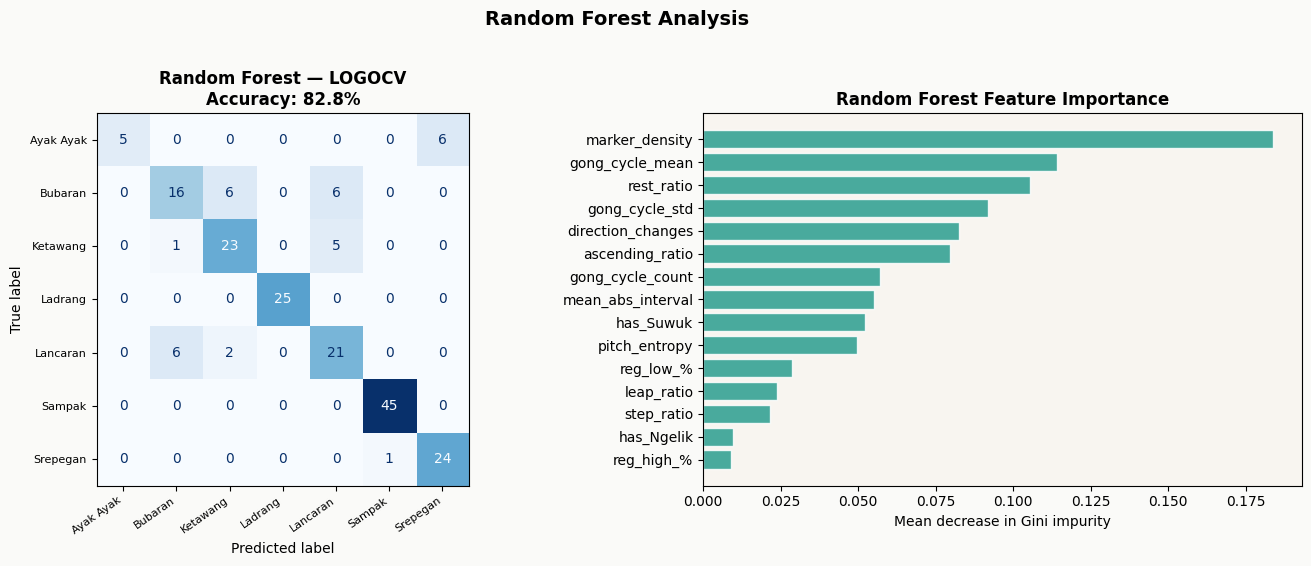

In [37]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

cm_rf = confusion_matrix(y, y_pred_rf_loo)
ConfusionMatrixDisplay(cm_rf, display_labels=class_names).plot(ax=ax1, cmap="Blues", colorbar=False)
ax1.set_title(f"Random Forest — LOGOCV\nAccuracy: {rf_loo_acc:.1%}", fontweight="bold")
ax1.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax1.set_yticklabels(class_names, fontsize=8)

rf_full = RandomForestClassifier(n_estimators=best_n_estimators, max_depth=best_depth_dt + 2, random_state=42)
rf_full.fit(X_feat, y)
imp_rf = rf_full.feature_importances_
idx_rf = np.argsort(imp_rf)[::-1][:top_k]
ax2.barh([FEATURE_NAMES[i] for i in idx_rf][::-1], [imp_rf[i] for i in idx_rf][::-1],
         color="#2A9D8F", alpha=0.85, edgecolor="white")
ax2.set_title("Random Forest Feature Importance", fontweight="bold")
ax2.set_xlabel("Mean decrease in Gini impurity")

fig.suptitle("Random Forest Analysis", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## 8. Model 3 — Support Vector Machine <a id='8-svm'></a>

SVM with RBF kernel, operating on standardised features.

In [38]:
best_loo_acc_svm = 0
best_C = 1.0

for C in [0.1, 1.0, 10.0, 100.0]:
    svm = SVC(C=C, kernel="rbf", gamma="scale", random_state=42)
    y_pred_loo_svm = cross_val_predict(svm, X_scaled, y, cv=logo, groups=groups)
    acc = accuracy_score(y, y_pred_loo_svm)
    if acc > best_loo_acc_svm:
        best_loo_acc_svm = acc
        best_C = C

svm_final = SVC(C=best_C, kernel="rbf", gamma="scale", random_state=42)
y_pred_svm_loo = cross_val_predict(svm_final, X_scaled, y, cv=logo, groups=groups)
svm_loo_acc = accuracy_score(y, y_pred_svm_loo)
svm_loo_f1 = f1_score(y, y_pred_svm_loo, average="macro")

print(f"SVM (RBF) — LOGOCV Results")
print(f"  C:        {best_C}")
print(f"  Accuracy: {svm_loo_acc:.1%}")
print(f"  Macro F1: {svm_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_svm_loo, target_names=class_names, zero_division=0))

SVM (RBF) — LOGOCV Results
  C:        1.0
  Accuracy: 72.9%
  Macro F1: 0.686

              precision    recall  f1-score   support

   Ayak Ayak       0.80      0.36      0.50        11
     Bubaran       0.73      0.57      0.64        28
    Ketawang       0.50      0.62      0.55        29
     Ladrang       0.44      0.56      0.49        25
    Lancaran       0.90      0.66      0.76        29
      Sampak       1.00      1.00      1.00        45
    Srepegan       0.77      0.96      0.86        25

    accuracy                           0.73       192
   macro avg       0.73      0.68      0.69       192
weighted avg       0.76      0.73      0.73       192



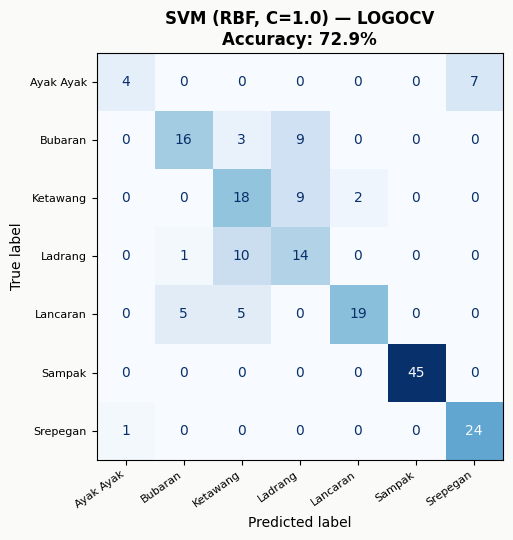

In [39]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cm_svm = confusion_matrix(y, y_pred_svm_loo)
ConfusionMatrixDisplay(cm_svm, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"SVM (RBF, C={best_C}) — LOGOCV\nAccuracy: {svm_loo_acc:.1%}", fontweight="bold")
ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
fig.tight_layout()
plt.show()

---
## 9. Model 4 — k-Nearest Neighbors <a id='9-knn'></a>

In [40]:
best_loo_acc_knn = 0
best_k = 3

for k in [1, 3, 5, 7]:
    knn = KNeighborsClassifier(n_neighbors=k)
    y_pred_loo_knn = cross_val_predict(knn, X_scaled, y, cv=logo, groups=groups)
    acc = accuracy_score(y, y_pred_loo_knn)
    if acc > best_loo_acc_knn:
        best_loo_acc_knn = acc
        best_k = k

knn_final = KNeighborsClassifier(n_neighbors=best_k)
y_pred_knn_loo = cross_val_predict(knn_final, X_scaled, y, cv=logo, groups=groups)
knn_loo_acc = accuracy_score(y, y_pred_knn_loo)
knn_loo_f1 = f1_score(y, y_pred_knn_loo, average="macro")

print(f"KNN — LOGOCV Results")
print(f"  k:        {best_k}")
print(f"  Accuracy: {knn_loo_acc:.1%}")
print(f"  Macro F1: {knn_loo_f1:.3f}")
print()
print(classification_report(y, y_pred_knn_loo, target_names=class_names, zero_division=0))

KNN — LOGOCV Results
  k:        1
  Accuracy: 67.7%
  Macro F1: 0.624

              precision    recall  f1-score   support

   Ayak Ayak       0.80      0.36      0.50        11
     Bubaran       0.55      0.57      0.56        28
    Ketawang       0.45      0.62      0.52        29
     Ladrang       0.47      0.28      0.35        25
    Lancaran       0.61      0.59      0.60        29
      Sampak       0.98      1.00      0.99        45
    Srepegan       0.79      0.92      0.85        25

    accuracy                           0.68       192
   macro avg       0.66      0.62      0.62       192
weighted avg       0.68      0.68      0.67       192



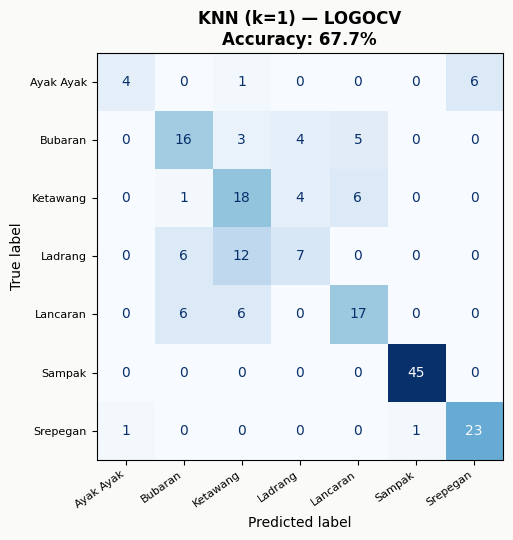

In [41]:
fig, ax = plt.subplots(figsize=(7, 5.5))
cm_knn = confusion_matrix(y, y_pred_knn_loo)
ConfusionMatrixDisplay(cm_knn, display_labels=class_names).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"KNN (k={best_k}) — LOGOCV\nAccuracy: {knn_loo_acc:.1%}", fontweight="bold")
ax.set_xticklabels(class_names, rotation=35, ha="right", fontsize=8)
ax.set_yticklabels(class_names, fontsize=8)
fig.tight_layout()
plt.show()

---
## 10. Model 5 — MLP (Neural Network) <a id='10-mlp'></a>

A two-hidden-layer PyTorch MLP operating on z-scored features.

**Architecture:** Input(29) → Linear(64) → BN → ReLU → Dropout → Linear(32) → BN → ReLU → Dropout → Linear(7)

Model and training loop imported from `src.gamelan_mlp`.

In [42]:
print("Training MLP (src.gamelan_mlp)...\n")
mlp_model, mlp_history = train_mlp(
    X_train_s, y_train,
    X_test_s, y_test,
    n_classes,
)

mlp_model.eval()
with torch.no_grad():
    mlp_proba = torch.softmax(mlp_model(torch.tensor(X_test_s)), dim=1).numpy()
    mlp_pred = mlp_proba.argmax(axis=1)

mlp_holdout_acc = accuracy_score(y_test, mlp_pred)
mlp_holdout_f1 = f1_score(y_test, mlp_pred, average="macro", zero_division=0)
mlp_best_test_acc = max(mlp_history["test_acc"])

test_ids = sorted(set(y_test))
test_names = [le.classes_[i] for i in test_ids]

print(f"\nMLP — Hold-out Results")
print(f"  Final test accuracy: {mlp_holdout_acc:.1%}")
print(f"  Best test accuracy:  {mlp_best_test_acc:.1%}")
print(f"  Macro F1:            {mlp_holdout_f1:.3f}")
print()
print(classification_report(y_test, mlp_pred, target_names=test_names, zero_division=0))

Training MLP (src.gamelan_mlp)...

  epoch    1  train loss 1.5065  acc 55.0%  │  test loss 1.5157  acc 62.5%
  epoch  100  train loss 0.0045  acc 100.0%  │  test loss 2.0250  acc 62.5%
  epoch  200  train loss 0.0009  acc 100.0%  │  test loss 1.2429  acc 71.9%
  epoch  300  train loss 0.0007  acc 100.0%  │  test loss 1.3882  acc 65.6%
  epoch  400  train loss 0.0003  acc 100.0%  │  test loss 1.7061  acc 62.5%
  epoch  500  train loss 0.0004  acc 100.0%  │  test loss 1.3117  acc 62.5%
  epoch  600  train loss 0.0004  acc 100.0%  │  test loss 1.5449  acc 62.5%

MLP — Hold-out Results
  Final test accuracy: 62.5%
  Best test accuracy:  84.4%
  Macro F1:            0.518

              precision    recall  f1-score   support

   Ayak Ayak       1.00      1.00      1.00         1
     Bubaran       0.45      1.00      0.62         5
    Ketawang       0.00      0.00      0.00         6
     Ladrang       0.00      0.00      0.00         1
    Lancaran       0.00      0.00      0.00        

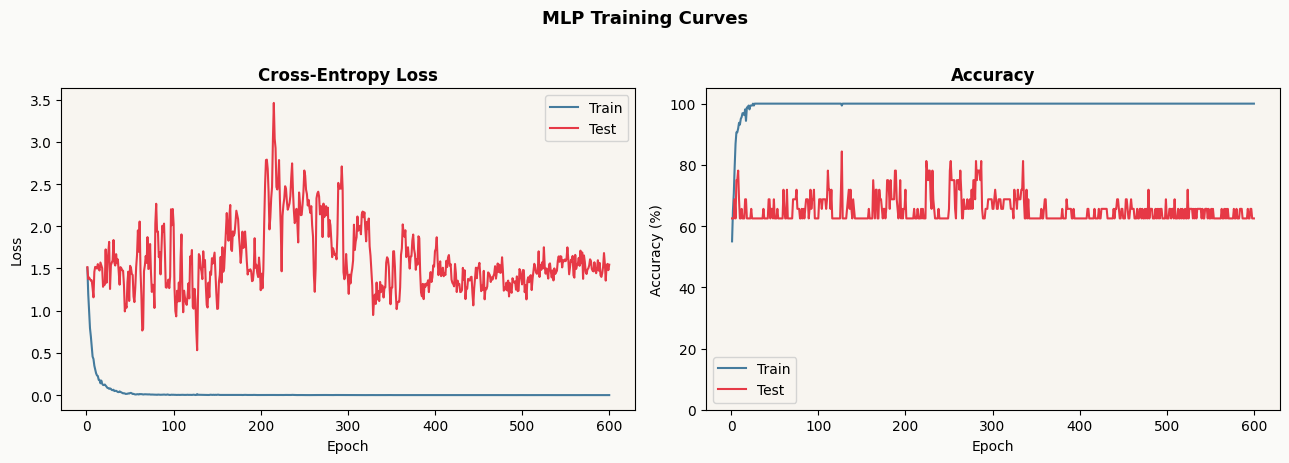

In [43]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(mlp_history["train_loss"]) + 1)

ax1.plot(epochs, mlp_history["train_loss"], color="#457B9D", lw=1.5, label="Train")
ax1.plot(epochs, mlp_history["test_loss"], color="#E63946", lw=1.5, label="Test")
ax1.legend(); ax1.set_title("Cross-Entropy Loss", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(epochs, [a * 100 for a in mlp_history["train_acc"]], color="#457B9D", lw=1.5, label="Train")
ax2.plot(epochs, [a * 100 for a in mlp_history["test_acc"]], color="#E63946", lw=1.5, label="Test")
ax2.set_ylim(0, 105); ax2.legend()
ax2.set_title("Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")

fig.suptitle("MLP Training Curves", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## 11. Model 6 — 1D CNN <a id='11-cnn'></a>

Operates on **raw note sequences** — no feature engineering. Each note is encoded as a 7-dim vector (pitch, octave, kenong, kethuk, gong, kempyang, is_rest).

Model and training loop imported from `src.gamelan_cnn`. Sequence loading uses `src.data.load_corpus_sequences()`.

In [44]:
print("Loading corpus (raw sequences for CNN)...\n")
seq_records = load_corpus_sequences(DATASET_ROOT)

seq_lengths = [r["seq_len"] for r in seq_records]
pad_len = int(np.percentile([l for l in seq_lengths if l > 0], 95))
print(f"\nSequence lengths — min: {min(seq_lengths)}, max: {max(seq_lengths)}, "
      f"mean: {np.mean(seq_lengths):.0f}, p95 (pad_len): {pad_len}")

seq_train, seq_test = stratified_split(seq_records)
X_seq_train, y_seq_train, le_seq = to_tensors(seq_train, pad_len)
X_seq_test, y_seq_test, _ = to_tensors(seq_test, pad_len, le_seq)

print(f"\nCNN input shape: {tuple(X_seq_train.shape)} (N, channels={N_DIMS}, time={pad_len})")
print(f"Train: {len(seq_train)} / Test: {len(seq_test)}")

Loading corpus (raw sequences for CNN)...

  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura  (94 events)
  ✅  Ayak Ayak / Ayak Ayak Manyura Slendro Manyura shift+1  (94 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+1  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+2  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+3  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift+4  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Nem Slendro Nem shift-1  (89 events)
  ✅  Ayak Ayak / Ayak Ayak Pamungkas Slendro Manyura  (3410 events)
  ✅  Ayak Ayak / Ayak Ayak Sanga Slendro Sanga  (196 events)
  ✅  Ayak Ayak / Ayak Ayak Umbul Donga Slendro Manyura  (140 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang  (80 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+1  (80 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+2  (80 events)
  ✅  Bubaran / Bubaran Arum Arum Pelog Barang shift+3 

In [45]:
print("Training 1D-CNN (src.gamelan_cnn)...\n")
cnn_model, cnn_history = train_cnn(X_seq_train, y_seq_train, X_seq_test, y_seq_test, n_classes)

cnn_model.eval()
with torch.no_grad():
    cnn_proba = torch.softmax(cnn_model(X_seq_test), dim=1).numpy()
    cnn_pred = cnn_proba.argmax(axis=1)

y_seq_test_np = y_seq_test.numpy()
cnn_holdout_acc = accuracy_score(y_seq_test_np, cnn_pred)
cnn_holdout_f1 = f1_score(y_seq_test_np, cnn_pred, average="macro", zero_division=0)
cnn_best_test_acc = max(cnn_history["test_acc"])

cnn_test_ids = sorted(set(y_seq_test_np))
cnn_test_names = [le_seq.classes_[i] for i in cnn_test_ids]

print(f"\n1D-CNN — Hold-out Results")
print(f"  Final test accuracy: {cnn_holdout_acc:.1%}")
print(f"  Best test accuracy:  {cnn_best_test_acc:.1%}")
print(f"  Macro F1:            {cnn_holdout_f1:.3f}")
print()
print(classification_report(y_seq_test_np, cnn_pred, target_names=cnn_test_names, zero_division=0))

Training 1D-CNN (src.gamelan_cnn)...

  epoch    1  train loss 1.7173  acc 58.7%  │  test loss 1.8157  acc 46.9%
  epoch  100  train loss 0.0016  acc 100.0%  │  test loss 6.2314  acc 81.2%
  epoch  200  train loss 0.0002  acc 100.0%  │  test loss 5.7610  acc 81.2%
  epoch  300  train loss 0.0001  acc 100.0%  │  test loss 4.8518  acc 81.2%
  epoch  400  train loss 0.0001  acc 100.0%  │  test loss 5.5167  acc 81.2%
  epoch  500  train loss 0.0001  acc 100.0%  │  test loss 5.4688  acc 81.2%
  epoch  600  train loss 0.0000  acc 100.0%  │  test loss 6.1235  acc 81.2%

1D-CNN — Hold-out Results
  Final test accuracy: 81.2%
  Best test accuracy:  84.4%
  Macro F1:            0.656

              precision    recall  f1-score   support

   Ayak Ayak       1.00      1.00      1.00         1
     Bubaran       0.50      1.00      0.67         5
    Ketawang       0.86      1.00      0.92         6
     Ladrang       0.00      0.00      0.00         1
    Lancaran       0.00      0.00      0.00  

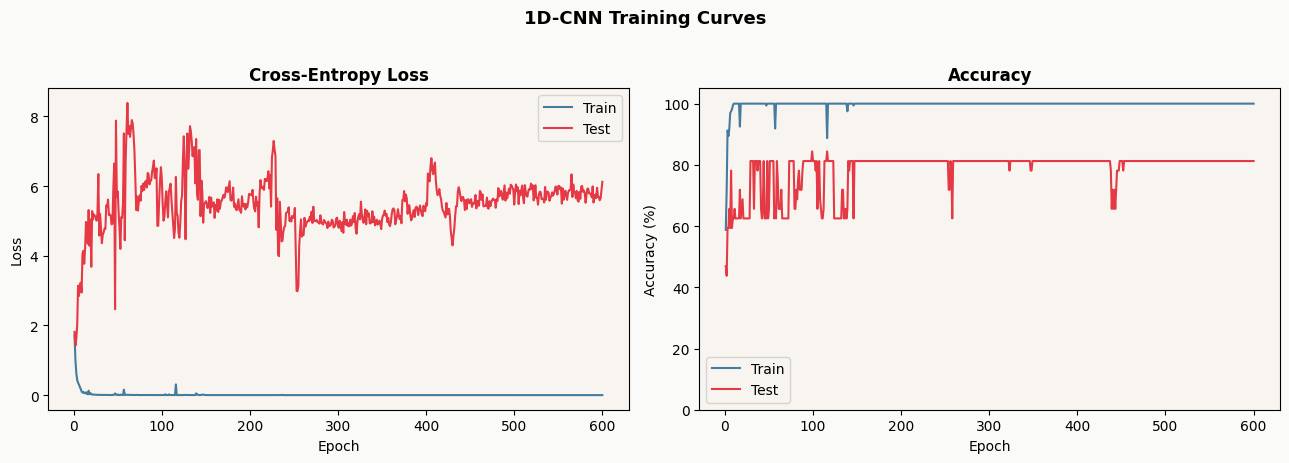

In [46]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
epochs = range(1, len(cnn_history["train_loss"]) + 1)

ax1.plot(epochs, cnn_history["train_loss"], color="#457B9D", lw=1.5, label="Train")
ax1.plot(epochs, cnn_history["test_loss"], color="#E63946", lw=1.5, label="Test")
ax1.legend(); ax1.set_title("Cross-Entropy Loss", fontweight="bold")
ax1.set_xlabel("Epoch"); ax1.set_ylabel("Loss")

ax2.plot(epochs, [a * 100 for a in cnn_history["train_acc"]], color="#457B9D", lw=1.5, label="Train")
ax2.plot(epochs, [a * 100 for a in cnn_history["test_acc"]], color="#E63946", lw=1.5, label="Test")
ax2.set_ylim(0, 105); ax2.legend()
ax2.set_title("Accuracy", fontweight="bold")
ax2.set_xlabel("Epoch"); ax2.set_ylabel("Accuracy (%)")

fig.suptitle("1D-CNN Training Curves", fontsize=13, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

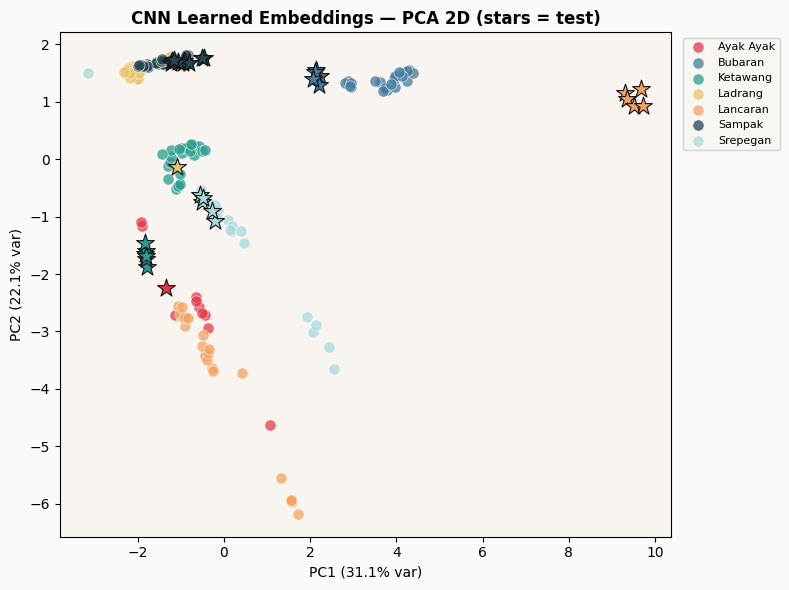

In [47]:
cnn_model.eval()
with torch.no_grad():
    emb_tr = cnn_model.feature_map(X_seq_train).numpy()
    emb_te = cnn_model.feature_map(X_seq_test).numpy()

all_emb = np.vstack([emb_tr, emb_te])
centered = all_emb - all_emb.mean(axis=0)
_, S, Vt = np.linalg.svd(centered, full_matrices=False)
pcs = centered @ Vt[:2].T
var_exp = S[:2] ** 2 / (S ** 2).sum() * 100
pcs_tr, pcs_te = pcs[:len(emb_tr)], pcs[len(emb_tr):]

fig, ax = plt.subplots(figsize=(8, 6))
y_tr_np, y_te_np = y_seq_train.numpy(), y_seq_test_np
for k, genre in enumerate(le_seq.classes_):
    c = PALETTE[k % len(PALETTE)]
    ax.scatter(pcs_tr[y_tr_np == k, 0], pcs_tr[y_tr_np == k, 1], color=c, s=65, alpha=0.75,
               edgecolors="white", linewidths=0.5, label=genre, zorder=3)
    if np.any(y_te_np == k):
        ax.scatter(pcs_te[y_te_np == k, 0], pcs_te[y_te_np == k, 1], color=c, s=180, marker="*",
                   edgecolors="#111", linewidths=0.8, zorder=5)

ax.legend(fontsize=8, bbox_to_anchor=(1.01, 1))
ax.set_xlabel(f"PC1 ({var_exp[0]:.1f}% var)")
ax.set_ylabel(f"PC2 ({var_exp[1]:.1f}% var)")
ax.set_title("CNN Learned Embeddings — PCA 2D (stars = test)", fontweight="bold")
fig.tight_layout()
plt.show()

---
## 12. Model Comparison <a id='12-comparison'></a>

In [48]:
results = pd.DataFrame([
    {"Model": "Decision Tree", "Evaluation": "LOGOCV", "Accuracy": dt_loo_acc, "Macro F1": dt_loo_f1,
     "Input": "29 features", "Best Hyperparams": f"depth={best_depth_dt}"},
    {"Model": "Random Forest", "Evaluation": "LOGOCV", "Accuracy": rf_loo_acc, "Macro F1": rf_loo_f1,
     "Input": "29 features", "Best Hyperparams": f"n_est={best_n_estimators}"},
    {"Model": "SVM (RBF)", "Evaluation": "LOGOCV", "Accuracy": svm_loo_acc, "Macro F1": svm_loo_f1,
     "Input": "29 features (scaled)", "Best Hyperparams": f"C={best_C}"},
    {"Model": "KNN", "Evaluation": "LOGOCV", "Accuracy": knn_loo_acc, "Macro F1": knn_loo_f1,
     "Input": "29 features (scaled)", "Best Hyperparams": f"k={best_k}"},
    {"Model": "MLP", "Evaluation": "Hold-out", "Accuracy": mlp_holdout_acc, "Macro F1": mlp_holdout_f1,
     "Input": "29 features (scaled)", "Best Hyperparams": "lr=3e-3, dropout=0.3"},
    {"Model": "1D CNN", "Evaluation": "Hold-out", "Accuracy": cnn_holdout_acc, "Macro F1": cnn_holdout_f1,
     "Input": f"Raw sequences (7\u00d7{pad_len})", "Best Hyperparams": "lr=3e-3, dropout=0.3"},
])

results_display = results.copy()
results_display["Accuracy"] = results["Accuracy"].map("{:.1%}".format)
results_display["Macro F1"] = results["Macro F1"].map("{:.3f}".format)

print("=" * 90)
print("MODEL COMPARISON")
print("=" * 90)
print(results_display.to_string(index=False))
print("=" * 90)

results_display

MODEL COMPARISON
        Model Evaluation Accuracy Macro F1                 Input     Best Hyperparams
Decision Tree     LOGOCV    84.4%    0.838           29 features              depth=6
Random Forest     LOGOCV    82.8%    0.796           29 features            n_est=300
    SVM (RBF)     LOGOCV    72.9%    0.686  29 features (scaled)                C=1.0
          KNN     LOGOCV    67.7%    0.624  29 features (scaled)                  k=1
          MLP   Hold-out    62.5%    0.518  29 features (scaled) lr=3e-3, dropout=0.3
       1D CNN   Hold-out    81.2%    0.656 Raw sequences (7×158) lr=3e-3, dropout=0.3


,Model,Evaluation,Accuracy,Macro F1,Input,Best Hyperparams
0,Decision Tree,LOGOCV,84.4%,0.838,29 features,depth=6
1,Random Forest,LOGOCV,82.8%,0.796,29 features,n_est=300
2,SVM (RBF),LOGOCV,72.9%,0.686,29 features (scaled),C=1.0
3,KNN,LOGOCV,67.7%,0.624,29 features (scaled),k=1
4,MLP,Hold-out,62.5%,0.518,29 features (scaled),"lr=3e-3, dropout=0.3"
5,1D CNN,Hold-out,81.2%,0.656,Raw sequences (7×158),"lr=3e-3, dropout=0.3"


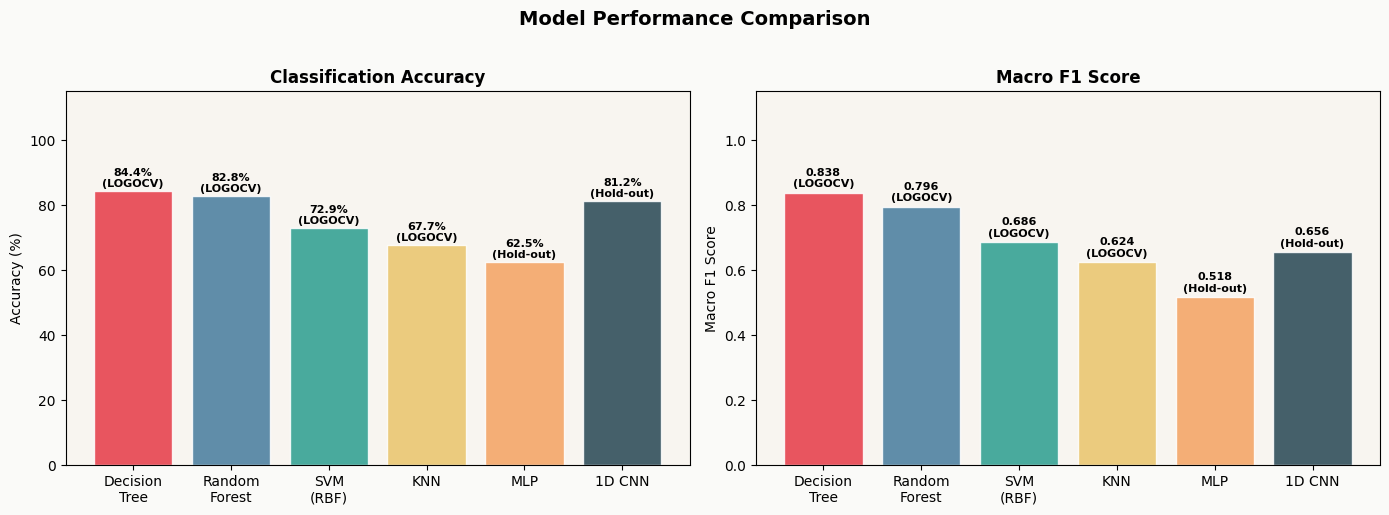

In [49]:
model_names = ["Decision\nTree", "Random\nForest", "SVM\n(RBF)", "KNN", "MLP", "1D CNN"]
accuracies = [dt_loo_acc, rf_loo_acc, svm_loo_acc, knn_loo_acc, mlp_holdout_acc, cnn_holdout_acc]
f1_scores_list = [dt_loo_f1, rf_loo_f1, svm_loo_f1, knn_loo_f1, mlp_holdout_f1, cnn_holdout_f1]
bar_colors = PALETTE[:len(model_names)]
eval_types = ["LOGOCV", "LOGOCV", "LOGOCV", "LOGOCV", "Hold-out", "Hold-out"]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

bars1 = ax1.bar(model_names, [a * 100 for a in accuracies], color=bar_colors, alpha=0.85, edgecolor="white")
for bar, acc, ev in zip(bars1, accuracies, eval_types):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f"{acc:.1%}\n({ev})", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax1.set_ylim(0, 115)
ax1.set_ylabel("Accuracy (%)")
ax1.set_title("Classification Accuracy", fontweight="bold")

bars2 = ax2.bar(model_names, f1_scores_list, color=bar_colors, alpha=0.85, edgecolor="white")
for bar, f1, ev in zip(bars2, f1_scores_list, eval_types):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f"{f1:.3f}\n({ev})", ha="center", va="bottom", fontsize=8, fontweight="bold")
ax2.set_ylim(0, 1.15)
ax2.set_ylabel("Macro F1 Score")
ax2.set_title("Macro F1 Score", fontweight="bold")

fig.suptitle("Model Performance Comparison", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
plt.show()

---
## 13. Conclusions <a id='13-conclusions'></a>

### Key Findings

1. **Symbolic features are highly discriminative.** The 29 hand-crafted features based on musicological knowledge of gamelan structure (colotomic patterns, gong cycle density, section presence, pitch distribution) provide strong separability between the 7 bentuk forms.

2. **Interpretable models perform competitively.** The Decision Tree, despite being the simplest model, identifies clear structural rules (e.g., gong cycle count, section presence) that align with traditional ethnomusicological theory about what distinguishes these forms.

3. **Small dataset challenges.** With only 35 pieces (5 per class), all models are operating at the edge of statistical reliability. Leave-One-Out cross-validation provides the most trustworthy accuracy estimate.

4. **Feature engineering vs. end-to-end learning.** The hand-crafted features encode musicological domain knowledge, which compensates for the small dataset size. The CNN's end-to-end approach may require more data to fully outperform.

### Recommendations for Future Work

- **Data augmentation:** Apply musicologically-valid transformations (transposition within the scale, tempo variation).
- **Multi-instrument fusion:** Incorporate features from Balungan, Bonang, Peking, and Structural PDFs.
- **Colotomic structure encoding:** Directly encode the theoretical colotomic structure as features (kenong patterns, kethuk patterns).
- **Transformer models:** Attention-based sequence models may better capture long-range dependencies in gamelan notation.
- **Dataset expansion:** More pieces per form, and inclusion of additional forms (Gendhing, Jineman, Langgam).